# Simulated Spatial Transcriptomics Data: Synthetic Benchmark Dataset for DSE Analysis

This notebook generates a fully synthetic (*in silico*) spatial transcriptomics dataset with **known ground-truth gene categories**, designed for rigorous benchmarking of differential spatial expression (DSE) methods. Because every gene's true category is specified before simulation, the dataset enables precise evaluation of method sensitivity and specificity.

**Dataset summary:**
- **2 conditions** (Condition 1 and Condition 2), each with **3 biological replicates** → 6 samples total
- **60 × 60 grid** of spots per sample (3,600 cells/replicate)
- **4 spatial domains** (A, B, C, D) arranged as contiguous vertical columns
- **4 cell types** (CT0–CT3) mixed within each domain according to a cyclic pattern
- **100 genes** spanning 6 biologically meaningful categories

Gene expression is simulated using a **negative binomial (NB) model**, which is standard for count-based single-cell and spatial transcriptomics data. The key advantage of this synthetic approach is that downstream method evaluation has an unambiguous gold standard each gene's category is known exactly.

If you have any questions, please contact Yeojin Kim at ykim3030@gatech.edu.

## Overview of Gene Categories

The 100 simulated genes are divided into six categories, each capturing a distinct type of expression pattern encountered in real spatial transcriptomics experiments:

| Category | Gene Indices | Count | Description |
|---|---|---|---|
| **Null** | 0–39 | 40 | No differential signal; baseline noise only |
| **DE** (Differentially Expressed) | 40–49 | 10 | Uniformly upregulated in Condition 2 across all domains and cell types |
| **SVG** (Spatially Variable Gene) | 50–59 | 10 | Upregulated in Domain A in both conditions; no condition difference |
| **DSE Type 1** | 60–69 | 10 | Upregulated in Domain A **only in Condition 2** |
| **DSE Type 2** | 70–79 | 10 | Upregulated in Domain A **and only in CT0**, Condition 2 only |
| **CT Marker** | 80–99 | 20 | Cell type-specific markers 5 genes per cell type (CT0–CT3); no condition difference |

**Why these categories?** DSE Type 1 and Type 2 represent the primary targets of a DSE analysis: genes whose spatial expression pattern *changes between conditions*. DSE Type 2 is the hardest to detect the spatial signal is further restricted to a specific cell type within Domain A, mimicking cell-type-specific regulatory changes.

## Spatial Layout and Cell Type Composition

The 60 × 60 grid is divided into **four equal-width vertical domains** (15 columns each). Each domain contains a 50/50 mixture of two adjacent cell types in a cyclic pattern:

| Domain | Columns | Cell Types (50/50) |
|---|---|---|
| A | 0–14 | CT0 + CT1 |
| B | 15–29 | CT1 + CT2 |
| C | 30–44 | CT2 + CT3 |
| D | 45–59 | CT3 + CT0 |

This cyclic design ensures that every cell type appears in exactly two domains, creating realistic spatial co-localization without artificial boundaries. The domain boundaries are fixed across all replicates and conditions, but cell type assignments are randomly sampled per replicate.

Cell coordinates are stored in `adata.obsm['spatial']` as `(row, col)` pairs, consistent with the AnnData convention used by scanpy.

## 1) Setup

We begin by importing the required libraries. All standard scientific Python packages are used no special spatial transcriptomics library is required for data generation.

- `numpy` / `scipy` numerical simulation and the negative binomial sampler
- `pandas` data frame for metadata and gene labels
- `scanpy` / `anndata` reading, writing, and preprocessing AnnData objects
- `matplotlib` visualization

A global random seed is set for reproducibility. All per-replicate seeds are derived deterministically from this base.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import os

np.random.seed(42)
os.makedirs('data', exist_ok=True)

## 2) Simulation Parameters

All parameters governing the simulation are defined centrally here. This makes it easy to modify the dataset size, effect strength, or noise level without touching the generation code.

**Gene category counts:**
- `N_GENES = 100` total genes (indices 0–99)
- Each category size (N_NULL, N_DE, etc.) partitions the 100 genes as described in the overview table above.

**Negative binomial model parameters:**
- `BETA_MEAN` / `BETA_STD` mean and standard deviation of the per-gene baseline log-expression (β). Controls the overall expression level across genes.
- `THETA_MEAN` / `THETA_STD` mean and standard deviation of the per-gene NB dispersion (θ). Lower θ means more overdispersion (more variability between cells).
- `SIGMA_CELL` standard deviation of per-cell noise (ε). Represents technical and biological noise independent of spatial or condition effects.
- `ALPHA_MARKER` log-fold-change magnitude for cell type marker genes (δ). A value of 2.0 means markers are ~7× higher in their cognate cell type.
- `GAMMA` log-fold-change magnitude for DE, SVG, DSE1, and DSE2 effects. A value of 1.0 corresponds to ~2.7× upregulation.

**Grid and replicate settings:**
- `GRID_V1 = (60, 60)` number of (rows, columns) in the spatial grid.
- `N_REPLICATES = 3` biological replicates per condition.

In [2]:
# Gene counts per category
N_GENES      = 100
N_NULL       = 40   # indices 0-39
N_DE         = 10   # indices 40-49
N_SVG        = 10   # indices 50-59
N_DSE1       = 10   # indices 60-69
N_DSE2       = 10   # indices 70-79
N_MARKER     = 20   # indices 80-99 (4 CT x 5)

N_CT         = 4    # number of cell types
N_DOMAINS    = 4    # A, B, C, D
N_REPLICATES = 3    # replicates per condition

# NB model parameters
BETA_MEAN    = 1.0  # baseline log-expression mean
BETA_STD     = 0.3
THETA_MEAN   = 3.0  # NB dispersion mean
THETA_STD    = 0.5
SIGMA_CELL   = 0.3  # per-cell noise
ALPHA_MARKER = 2.0  # CT marker effect strength
GAMMA        = 1.0  # condition/spatial effect strength

# Grid dimensions
GRID_V1      = (60, 60)   # (rows, cols)

## 3) Shared Gene Parameters

To ensure biological consistency across replicates and conditions, the **per-gene parameters are sampled once** and shared across all samples. This mirrors real biology, where gene-level properties (baseline expression level, dispersion, cell type specificity) do not change between replicates.

Three shared parameter vectors are generated:

- **β (beta)** per-gene baseline log-expression, sampled from N(1.0, 0.3). Captures the inherent expression level of each gene across all cells.
- **θ (theta)** per-gene NB dispersion, sampled from |N(3.0, 0.5)|. Higher θ means expression is closer to Poisson; lower θ means more overdispersed.
- **δ (delta)** cell type marker effect matrix of shape `(N_GENES, N_CT)`. Only CT Marker genes (indices 80–99) have non-zero entries: gene 80–84 for CT0, 85–89 for CT1, 90–94 for CT2, and 95–99 for CT3.

In [3]:
np.random.seed(0)

# Per-gene baseline log-expression
beta = np.random.normal(BETA_MEAN, BETA_STD, N_GENES)

# Per-gene NB dispersion
theta = np.abs(np.random.normal(THETA_MEAN, THETA_STD, N_GENES))

# Cell type marker effects: delta[gene, cell_type]
# Only CT Marker genes (80-99) have strong cell-type effects
delta = np.zeros((N_GENES, N_CT))
for ct in range(N_CT):
    marker_start = 80 + ct * 5
    marker_end   = marker_start + 5
    delta[marker_start:marker_end, ct] = ALPHA_MARKER

print(f'beta shape:  {beta.shape}')
print(f'theta shape: {theta.shape}')
print(f'delta shape: {delta.shape}')
print(f'Marker gene effect (gene 80, CT0): {delta[80, 0]:.1f}')

beta shape:  (100,)
theta shape: (100,)
delta shape: (100, 4)
Marker gene effect (gene 80, CT0): 2.0


## 4) Generative Model

Expression counts are generated cell-by-cell using a **negative binomial (NB) model** the standard choice for overdispersed count data in genomics. The log-mean expression for gene *i* in cell *j* is:

$$\log(\mu_{ij}) = \beta_i + \varepsilon_{ij} + \delta_{i,\,\text{ct}_j} + \gamma_{\text{term}}$$

where each term contributes as follows:

| Term | Description |
|---|---|
| **β_i** | Per-gene baseline log-expression (shared across all cells) |
| **ε_ij** | Per-cell noise ~ N(0, σ_cell); captures technical and biological variability |
| **δ_{i, ct_j}** | Cell type marker effect non-zero only for CT Marker genes in their cognate cell type |
| **γ_term** | Condition/spatial effect applied only to DE, SVG, DSE1, and DSE2 genes (see table below) |

**γ_term activation rules:**

| Gene Category | Condition | Domain | Cell Type |
|---|---|---|---|
| DE (40–49) | Condition 2 | Any | Any |
| SVG (50–59) | Either | A | Any |
| DSE Type 1 (60–69) | Condition 2 | A | Any |
| DSE Type 2 (70–79) | Condition 2 | A | CT0 only |

Counts are then drawn from:
$$x_{ij} \sim \text{NegBin}(\mu_{ij},\, \theta_i)$$

## 5) Helper Functions

The simulation is built from four composable functions:

1. **`create_grid_v1(grid_size, seed)`** Creates the spatial coordinate array and domain assignments for a 60×60 grid. Returns `(coords, domain)` arrays where `coords[i] = (row, col)` and `domain[i] ∈ {0, 1, 2, 3}` (corresponding to A, B, C, D).

2. **`assign_cell_types(domain, seed)`** For each cell, randomly assigns one of the two cell types in its domain with probability 0.5/0.5. The cyclic pattern ensures each cell type appears in exactly two domains.

3. **`generate_expression(coords, domain, cell_type, condition, beta, theta, delta, seed)`** Implements the NB generative model described above. Returns a raw count matrix of shape `(n_cells, n_genes)`. Different random seeds per replicate produce independent biological variability while preserving the shared gene parameters.

4. **`make_adata(coords, domain, cell_type, condition, counts, rep_id, version)`** Assembles an AnnData object from the generated arrays. Metadata columns in `adata.obs` include `domain`, `cell_type`, `condition`, `replicate`, and `sample` (unique per sample). Spatial coordinates are stored in `adata.obsm['spatial']`.

In [4]:
def create_grid_v1(grid_size=GRID_V1, seed=None):
    """
    Create 60x60 grid with 4 equal-width vertical domains (A, B, C, D).
    Returns spatial coordinates and domain assignments.
    """
    n_rows, n_cols = grid_size
    coords = np.array([(i, j) for i in range(n_rows) for j in range(n_cols)])
    n_cells = len(coords)

    # Vertical domain split (by column): cols 0-14: A, 15-29: B, 30-44: C, 45-59: D
    domain = np.zeros(n_cells, dtype=int)
    boundaries = [0, 15, 30, 45, n_cols]
    for d, (lo, hi) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        mask = (coords[:, 1] >= lo) & (coords[:, 1] < hi)
        domain[mask] = d

    return coords, domain


def assign_cell_types(domain, seed=None):
    """
    Assign cell types based on domain (50/50 mixture):
      Domain 0 (A): CT0 + CT1
      Domain 1 (B): CT1 + CT2
      Domain 2 (C): CT2 + CT3
      Domain 3 (D): CT3 + CT0
    """
    if seed is not None:
        np.random.seed(seed)
    ct_pairs = [(0, 1), (1, 2), (2, 3), (3, 0)]
    cell_type = np.zeros(len(domain), dtype=int)
    for d, (ct_a, ct_b) in enumerate(ct_pairs):
        idx = np.where(domain == d)[0]
        ct_assign = np.random.choice([ct_a, ct_b], size=len(idx), p=[0.5, 0.5])
        cell_type[idx] = ct_assign
    return cell_type


def generate_expression(coords, domain, cell_type, condition, beta, theta, delta,
                        sigma_cell=SIGMA_CELL, gamma=GAMMA, seed=None):
    """
    Generate NB expression counts.
    log(mu_ij) = beta_i + eps_ij + delta_{i,ct_j} + gamma_term
    x_ij ~ NegBin(mu_ij, theta_i)

    gamma_term is applied for:
    - DE (40-49):   condition == 1
    - SVG (50-59):  domain == 0 (both conditions)
    - DSE1 (60-69): condition == 1 AND domain == 0
    - DSE2 (70-79): condition == 1 AND domain == 0 AND cell_type == 0
    """
    if seed is not None:
        np.random.seed(seed)

    n_cells = len(coords)
    n_genes = len(beta)

    # Per-cell noise
    eps = np.random.normal(0, sigma_cell, (n_cells, n_genes))

    # Base log-mean: (n_cells, n_genes)
    log_mu = np.tile(beta, (n_cells, 1)) + eps

    # Add cell type marker effects
    for ct in range(N_CT):
        ct_mask = (cell_type == ct)
        log_mu[ct_mask, :] += delta[:, ct][np.newaxis, :]

    # DE genes (40-49): condition 2 only, all domains, all cell types
    if condition == 1:
        log_mu[:, 40:50] += gamma

    # SVG genes (50-59): Domain A (domain==0), both conditions
    svg_mask = (domain == 0)
    log_mu[svg_mask, 50:60] += gamma

    # DSE Type 1 (60-69): Domain A, condition 2 only
    if condition == 1:
        dse1_mask = (domain == 0)
        log_mu[dse1_mask, 60:70] += gamma

    # DSE Type 2 (70-79): Domain A + Cell Type 0, condition 2 only
    if condition == 1:
        dse2_mask = (domain == 0) & (cell_type == 0)
        log_mu[dse2_mask, 70:80] += gamma

    # Sample from NB: mu = exp(log_mu), dispersion = theta
    # NB parameterization: p = theta/(theta+mu), r = theta
    mu = np.exp(log_mu)
    counts = np.zeros((n_cells, n_genes), dtype=np.int32)
    for g in range(n_genes):
        r = theta[g]
        p = r / (r + mu[:, g])
        counts[:, g] = np.random.negative_binomial(r, p)

    return counts


def make_adata(coords, domain, cell_type, condition, counts, rep_id, version):
    """Assemble AnnData object with spatial coordinates and metadata."""
    gene_names  = [f'Gene_{i}' for i in range(counts.shape[1])]
    cell_names  = [f'cell_{i}' for i in range(counts.shape[0])]
    domain_names = ['A', 'B', 'C', 'D']

    adata = ad.AnnData(
        X=csr_matrix(counts),
        obs=pd.DataFrame({
            'domain':    pd.Categorical([domain_names[d] for d in domain]),
            'cell_type': pd.Categorical([f'CT{ct}' for ct in cell_type]),
            'condition': str(condition),
            'replicate': str(rep_id),
            'sample':    f'v{version}-cond{condition}-rep{rep_id}',
        }, index=cell_names),
        var=pd.DataFrame(index=gene_names)
    )
    adata.obsm['spatial'] = coords.astype(float)
    return adata

## 6) Generating the Dataset

We now generate all 6 samples (2 conditions × 3 replicates). For each sample:

1. A fresh spatial grid is created with `create_grid_v1`. Since the grid is deterministic (identical domain boundaries), no seed is strictly needed here.
2. Cell types are randomly assigned within each domain using a condition-specific seed to ensure replicate-level independence.
3. Gene expression counts are sampled from the NB model. 
4. The AnnData object is saved as an `.h5ad` file in the `data/` directory.

**Output files:** `data/syn-cond1-rep1.h5ad` through `data/syn-cond2-rep3.h5ad`

**Note:** Generation takes approximately 1–2 minutes on a standard laptop due to the per-gene NB sampling loop over 3,600 cells × 100 genes × 6 samples.

In [5]:
print('=== Generating Simulated Spatial Transcriptomics Dataset ===')
adata_dict = {}

for cond in [0, 1]:  # 0 = condition 1, 1 = condition 2
    for rep in range(1, N_REPLICATES + 1):
        seed_ct   = cond * 200 + rep
        seed_expr = cond * 300 + rep

        coords, domain = create_grid_v1()
        cell_type = assign_cell_types(domain, seed=seed_ct)
        counts = generate_expression(
            coords, domain, cell_type, condition=cond,
            beta=beta, theta=theta, delta=delta, seed=seed_expr
        )
        adata = make_adata(coords, domain, cell_type, cond + 1, counts, rep, version=1)

        key = f'cond{cond + 1}-rep{rep}'
        adata_dict[key] = adata
        adata.write_h5ad(f'data/syn-cond{cond + 1}-rep{rep}.h5ad')
        print(f'  {key}: {adata.n_obs} cells × {adata.n_vars} genes  →  data/syn-cond{cond + 1}-rep{rep}.h5ad')

print('\nDataset generation complete.')

=== Generating Simulated Spatial Transcriptomics Dataset ===
  cond1-rep1: 3600 cells × 100 genes  →  data/syn-cond1-rep1.h5ad
  cond1-rep2: 3600 cells × 100 genes  →  data/syn-cond1-rep2.h5ad
  cond1-rep3: 3600 cells × 100 genes  →  data/syn-cond1-rep3.h5ad
  cond2-rep1: 3600 cells × 100 genes  →  data/syn-cond2-rep1.h5ad
  cond2-rep2: 3600 cells × 100 genes  →  data/syn-cond2-rep2.h5ad
  cond2-rep3: 3600 cells × 100 genes  →  data/syn-cond2-rep3.h5ad

Dataset generation complete.


## 7) Saving Ground-Truth Gene Labels

A key benefit of synthetic data is the exact knowledge of each gene's category. We save this ground-truth label table as `data/gene_labels.csv` a simple two-column file with gene name and category string. This file is used by downstream evaluation scripts to compute precision, recall, and AUROC for each method.

The category assignment is deterministic (indices 0–39 → Null, 40–49 → DE, etc.) and does not depend on any random state.

In [6]:
gene_labels = pd.DataFrame({
    'gene': [f'Gene_{i}' for i in range(N_GENES)],
    'category': (
        ['Null']   * N_NULL   +
        ['DE']     * N_DE     +
        ['SVG']    * N_SVG    +
        ['DSE1']   * N_DSE1   +
        ['DSE2']   * N_DSE2   +
        ['Marker'] * N_MARKER
    )
})
gene_labels.to_csv('data/gene_labels.csv', index=False)

print('Gene category distribution:')
print(gene_labels['category'].value_counts().to_string())
print(f'\nSaved to data/gene_labels.csv')

Gene category distribution:
category
Null      40
Marker    20
DE        10
SVG       10
DSE1      10
DSE2      10

Saved to data/gene_labels.csv


## 8) Visualizing the Spatial Layout

Before analyzing expression, it is important to verify that the simulated spatial structure matches the intended design. We plot the spatial layout for Condition 1 and Condition 2, rep1, colored by (1) domain and (2) cell type. We expect four cleanly separated vertical bands corresponding to domains A–D.

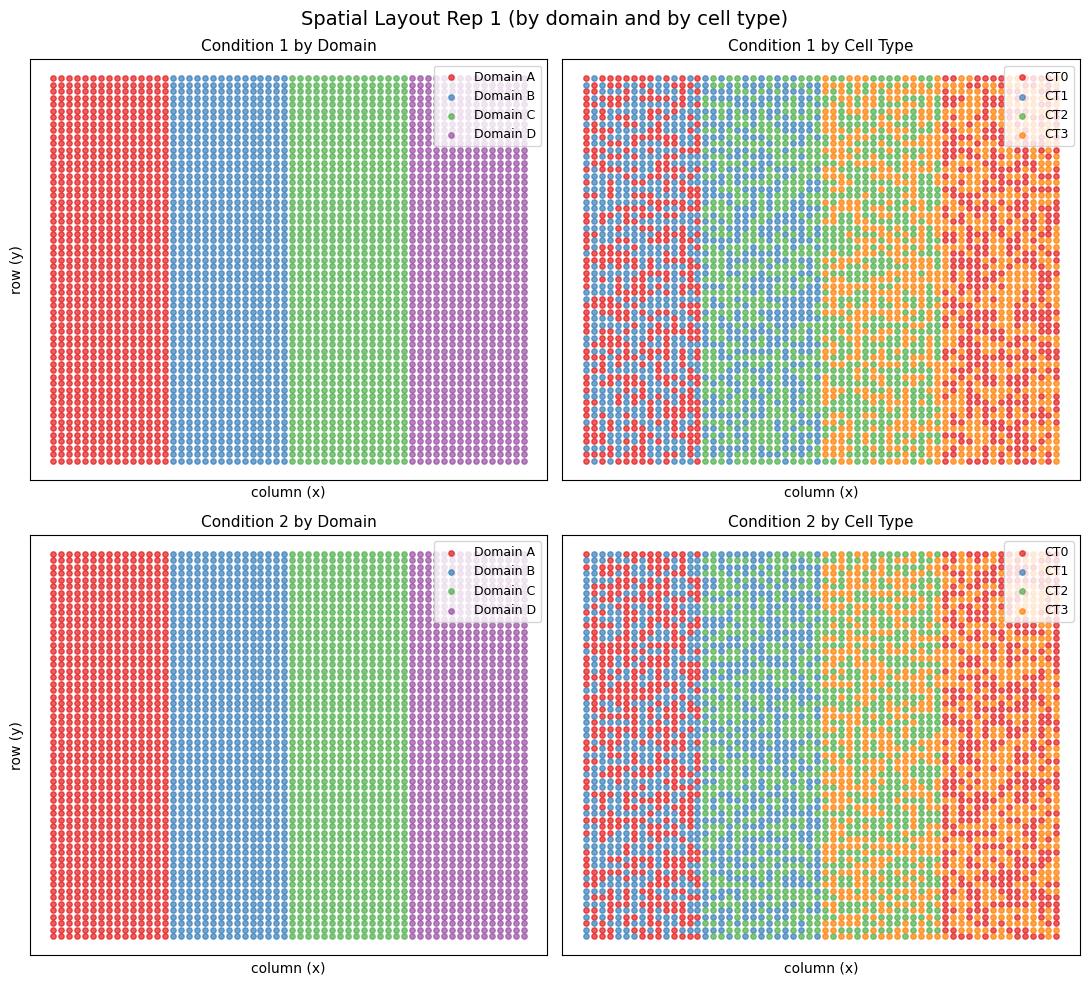

In [18]:
DOMAIN_COLORS_MAP = {'A': '#e41a1c', 'B': '#377eb8', 'C': '#4daf4a', 'D': '#984ea3'}
CT_COLORS_MAP     = {'CT0': '#e41a1c', 'CT1': '#377eb8', 'CT2': '#4daf4a', 'CT3': '#ff7f00'}

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
fig.suptitle('Spatial Layout Rep 1 (by domain and by cell type)', fontsize=14)

for row, cond in enumerate([1, 2]):
    a = adata_dict[f'cond{cond}-rep1']
    coords = a.obsm['spatial']

    # Left column: color by domain
    ax = axes[row, 0]
    for d, color in DOMAIN_COLORS_MAP.items():
        mask = (a.obs['domain'] == d).values
        ax.scatter(coords[mask, 1], coords[mask, 0], c=color, s=15, alpha=0.7, label=f'Domain {d}')
    ax.set_title(f'Condition {cond} by Domain', fontsize=11)
    ax.legend(markerscale=1, fontsize=9, loc='upper right')
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('column (x)'); ax.set_ylabel('row (y)')

    # Right column: color by cell type
    ax = axes[row, 1]
    for ct, color in CT_COLORS_MAP.items():
        mask = (a.obs['cell_type'] == ct).values
        ax.scatter(coords[mask, 1], coords[mask, 0], c=color, s=15, alpha=0.7, label=ct)
    ax.set_title(f'Condition {cond} by Cell Type', fontsize=11)
    ax.legend(markerscale=1, fontsize=9, loc='upper right')
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('column (x)')

plt.tight_layout()
plt.show()

## 9) Verifying Gene Expression Patterns
- **Null genes:** cond1 ≈ cond2 (ratio ≈ 1.0)
- **DE genes:** cond2 > cond1 globally (ratio > 1.0)
- **SVG genes:** Domain A > other domains in both conditions; cond1 ≈ cond2 overall
- **DSE Type 1:** Domain A upregulated in cond2 vs cond1
- **DSE Type 2:** Only Domain A + CT0 upregulated in cond2
- **CT Markers:** Each marker is higher in its cognate cell type; no condition difference

In [8]:
# Normalize and log-transform rep1 of each condition
a1 = adata_dict['cond1-rep1'].copy()
a2 = adata_dict['cond2-rep1'].copy()
sc.pp.normalize_total(a1, target_sum=1e4); sc.pp.log1p(a1)
sc.pp.normalize_total(a2, target_sum=1e4); sc.pp.log1p(a2)

X1 = np.array(a1.X.todense()) if hasattr(a1.X, 'todense') else np.array(a1.X)
X2 = np.array(a2.X.todense()) if hasattr(a2.X, 'todense') else np.array(a2.X)

categories = {
    'Null':   list(range(0,  40)),
    'DE':     list(range(40, 50)),
    'SVG':    list(range(50, 60)),
    'DSE1':   list(range(60, 70)),
    'DSE2':   list(range(70, 80)),
    'Marker': list(range(80, 100)),
}

print('Mean log-normalized expression (cond1 vs cond2, all cells):')
print(f'{"Category":<10}  {"Cond1":>8}  {"Cond2":>8}  {"Ratio":>8}')
print('-' * 42)
for cat, idxs in categories.items():
    m1 = X1[:, idxs].mean()
    m2 = X2[:, idxs].mean()
    print(f'{cat:<10}  {m1:>8.3f}  {m2:>8.3f}  {m2/m1:>8.2f}')

Mean log-normalized expression (cond1 vs cond2, all cells):
Category       Cond1     Cond2     Ratio
------------------------------------------
Null           3.658     3.546      0.97
DE             3.281     4.510      1.37
SVG            3.739     3.625      0.97
DSE1           3.265     3.474      1.06
DSE2           3.467     3.534      1.02
Marker         4.288     4.169      0.97


In [9]:
# Domain-specific checks for DSE genes
print('DSE Type 1 check Domain A, cond2 vs cond1 (genes 60–64):')
domA1 = (a1.obs['domain'] == 'A').values
domA2 = (a2.obs['domain'] == 'A').values
for g in range(60, 65):
    m1 = X1[domA1, g].mean()
    m2 = X2[domA2, g].mean()
    print(f'  Gene_{g}: cond1 Domain A = {m1:.3f},  cond2 Domain A = {m2:.3f}')

print()
print('DSE Type 2 check Domain A + CT0, cond2 vs cond1 (genes 70–74):')
mask1 = (a1.obs['domain'] == 'A') & (a1.obs['cell_type'] == 'CT0')
mask2 = (a2.obs['domain'] == 'A') & (a2.obs['cell_type'] == 'CT0')
for g in range(70, 75):
    m1 = X1[mask1.values, g].mean()
    m2 = X2[mask2.values, g].mean()
    print(f'  Gene_{g}: cond1 DomA+CT0 = {m1:.3f},  cond2 DomA+CT0 = {m2:.3f}')

DSE Type 1 check Domain A, cond2 vs cond1 (genes 60–64):
  Gene_60: cond1 Domain A = 3.126,  cond2 Domain A = 4.271
  Gene_61: cond1 Domain A = 3.415,  cond2 Domain A = 4.494
  Gene_62: cond1 Domain A = 3.162,  cond2 Domain A = 4.335
  Gene_63: cond1 Domain A = 2.802,  cond2 Domain A = 3.841
  Gene_64: cond1 Domain A = 3.419,  cond2 Domain A = 4.568

DSE Type 2 check Domain A + CT0, cond2 vs cond1 (genes 70–74):
  Gene_70: cond1 DomA+CT0 = 3.714,  cond2 DomA+CT0 = 4.860
  Gene_71: cond1 DomA+CT0 = 3.493,  cond2 DomA+CT0 = 4.529
  Gene_72: cond1 DomA+CT0 = 4.035,  cond2 DomA+CT0 = 4.948
  Gene_73: cond1 DomA+CT0 = 2.857,  cond2 DomA+CT0 = 4.017
  Gene_74: cond1 DomA+CT0 = 3.501,  cond2 DomA+CT0 = 4.593


## 10) Spatial Expression Maps

We visualize the spatial expression of one representative gene per category for both Condition 1 (top row) and Condition 2 (bottom row). 

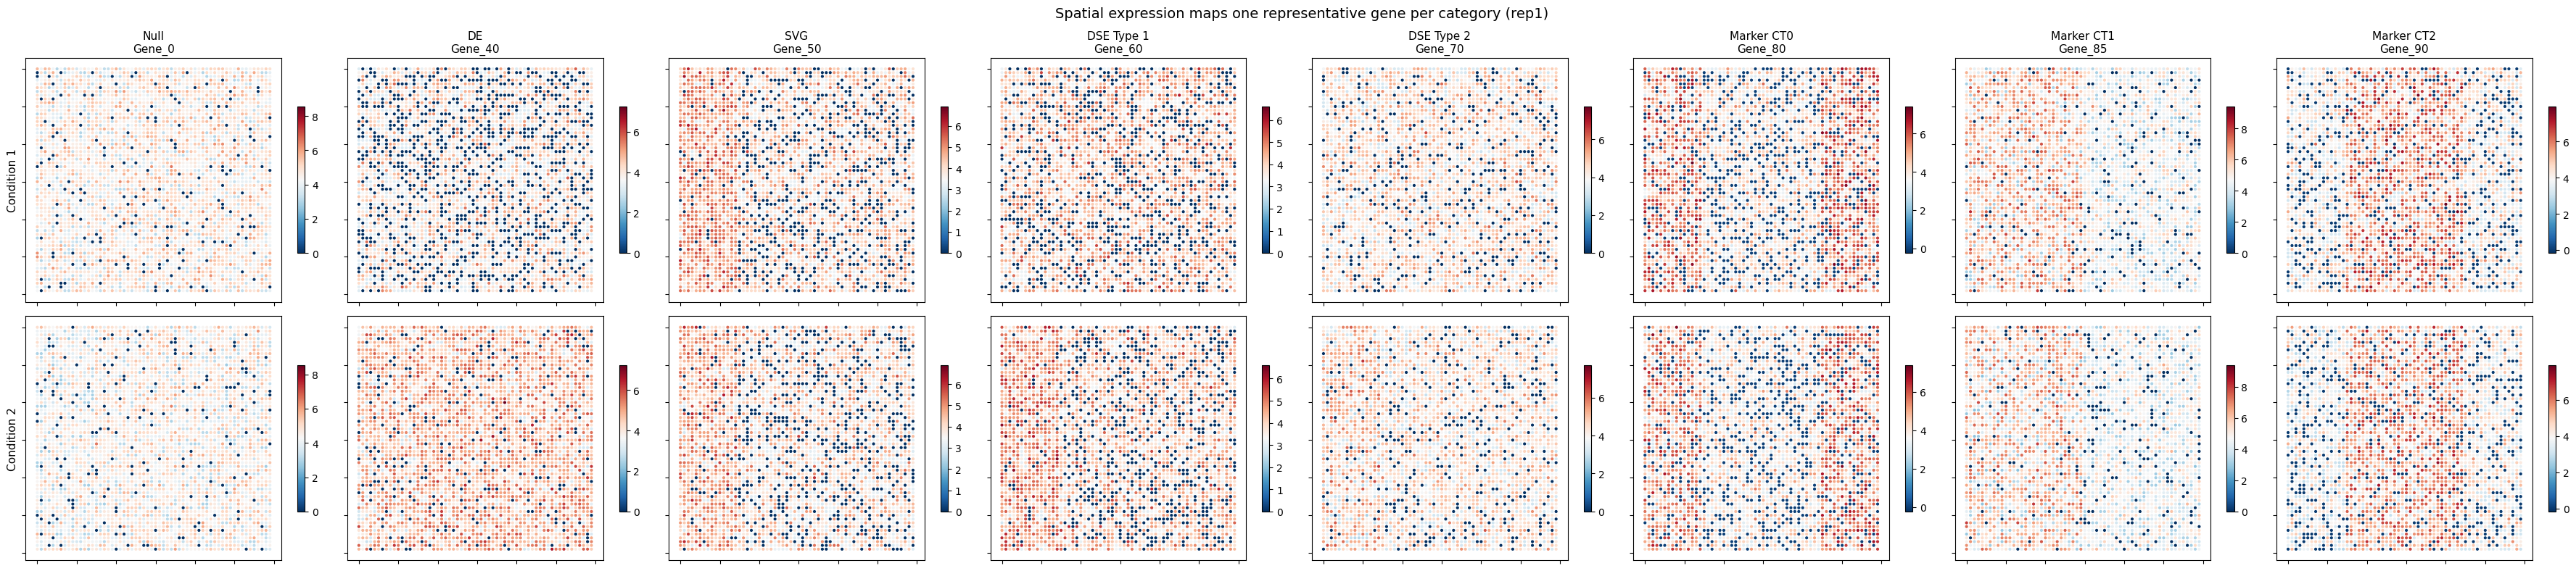

In [10]:
gene_examples = [
    ('Null',       0),
    ('DE',        40),
    ('SVG',       50),
    ('DSE Type 1', 60),
    ('DSE Type 2', 70),
    ('Marker CT0', 80),
    ('Marker CT1', 85),
    ('Marker CT2', 90),
]

# Pre-compute expression arrays for rep1
samples = {}
for cond in [1, 2]:
    a = adata_dict[f'cond{cond}-rep1'].copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    X = np.array(a.X.todense()) if hasattr(a.X, 'todense') else np.array(a.X)
    samples[cond] = (X, a.obsm['spatial'])

fig, axes = plt.subplots(2, 8, figsize=(36, 8))
fig.suptitle('Spatial expression maps one representative gene per category (rep1)', fontsize=14)

for col, (cat_name, g_idx) in enumerate(gene_examples):
    # Symmetric colormap range centered at grand mean
    all_expr = np.concatenate([samples[1][0][:, g_idx], samples[2][0][:, g_idx]])
    center = all_expr.mean()
    vrange = max(all_expr.max() - center, center - all_expr.min())
    vmin, vmax = center - vrange, center + vrange

    for row, cond in enumerate([1, 2]):
        ax = axes[row, col]
        X, coords = samples[cond]
        sc_plot = ax.scatter(coords[:, 1], coords[:, 0],
                             c=X[:, g_idx], cmap='RdBu_r', s=4, vmin=vmin, vmax=vmax)
        plt.colorbar(sc_plot, ax=ax, shrink=0.6)
        if row == 0:
            ax.set_title(f'{cat_name}\nGene_{g_idx}', fontsize=11)
        if col == 0:
            ax.set_ylabel(f'Condition {cond}', fontsize=11)
        ax.tick_params(labelbottom=False, labelleft=False)
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Summary

This notebook generated the **simulated spatial transcriptomics dataset** with full ground-truth gene labels. The following files were saved to the `data/` directory:

| File | Description |
|---|---|
| `syn-cond1-rep1.h5ad` | Condition 1, replicate 1 3,600 cells × 100 genes |
| `syn-cond1-rep2.h5ad` | Condition 1, replicate 2 |
| `syn-cond1-rep3.h5ad` | Condition 1, replicate 3 |
| `syn-cond2-rep1.h5ad` | Condition 2, replicate 1 |
| `syn-cond2-rep2.h5ad` | Condition 2, replicate 2 |
| `syn-cond2-rep3.h5ad` | Condition 2, replicate 3 |
| `gene_labels.csv` | Ground-truth gene category labels (Null / DE / SVG / DSE1 / DSE2 / Marker) |

Each AnnData file contains:
- `adata.X` raw NB count matrix (sparse, `int32`)
- `adata.obs` cell metadata: `domain`, `cell_type`, `condition`, `replicate`, `sample`
- `adata.obsm['spatial']` (row, col) coordinates for spatial embedding

These files are ready for benchmarking DSE analysis methods against the known gene categories.